In [3]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
import os
import sys
import pandas as pd
from datetime import datetime
sys.path.insert(1,'../src/')
import sbdynt as sbd

# Stability Indicators

Stability indicators can be produced in much the same way as the proper elements. 3 of the stability indicators provided by SBDynT can be computed directly from the default small_body integrations for proper elements, namely:
    (1) ACFI
    (2) Entropy
    (3) Power Distribution

The Clones Root Mean Square indicator can also be produced from the integration if clones were included in the above integration. 

In addition, if proper elements have already been computed, the Distance Metric stability indicator can be generated directly from the values contained within the small_body object. 



Stability indicators can be computed generally using the ``compute_stability`` function, which will compute stability indciators for every indicator which can be computed from the given simulation. For example, let us look at the process of computing stability indicators with the ``Lempo`` and ``Helga`` small_body objects below.

In [2]:
flag, tno_result, sim1 = sbd.run_tno(des='Lempo', clones=3, datadir='example_sims', deletefile=True, 
                         run_ML=False, run_proper=True, run_stability=True, logfile='screen')
flag, ast_result, sim2 = sbd.run_ast(des='Helga', clones=3, datadir='example_sims',deletefile=True, 
                         run_stability=True)

Initializing a TNO simulation instance by querying JPL
SBDB query results saved to example_sims/Lempo-Mar-17-2026.pkl

simulation epoch: 2458406.5

Rebound simulation initial conditions saved to example_sims/Lempo-ic.bin

Running additional forward integrations for the synthetic
proper elements and/or stability indicators calculation

Running Lempo from 0.0 to 75000000.0 years 
using mercurius outputting every 5000.0 years 
to simulation archivefile example_sims/Lempo-simarchive.bin
starting at 2026-03-17 14:15:10.120165

finishing at 2026-03-17 14:24:54.287015

Loaded integration for Lempo from example_sims/Lempo-ic.bin
simulation is at time 0.0 years
integrator is ias15

Found Lempo and 3 clones in the simulation

Running Lempo from 0.0 to -75000000.0 years 
using mercurius outputting every 5000.0 years 
to simulation archivefile example_sims/Lempo-simarchive.bin
starting at 2026-03-17 14:24:54.288013

finishing at 2026-03-17 14:34:22.918112

Reading in the TNO integration
proper ele


You may also run the full analysis using the ``run_existing_tno/ast`` functions, which perform the chaos indicator analysis using the simulation archive described by the inputs. 

In [4]:
flag, tno_result = sbd.analyze_tno_run(des='Lempo', clones=3, datadir='../example-notebooks/example_sims/',archivefile=None, 
                                     logfile=False,run_ML = False, run_proper=False, run_stability=True, output_arrays = True)

flag, ast_result = sbd.analyze_ast_run(des='Helga', clones=3, datadir='../example-notebooks/example_sims/',archivefile=None,
                                     logfile=False, run_proper=False, run_stability=True, output_arrays = True)

In [5]:
tno_result.stability_indicators.print_results()
print()
ast_result.stability_indicators.print_results()

Small Body:Lempo, Stability Indicator Results
ACFI: ( False ),  0.968  >  0.75
Entropy: ( False ),  0.9553648158247425  >  0.95
Power: ( True ),  0.5684496483110858  <  0.9
Distance Metric: Undefined
Clone_RMS_a: ( False ),  0.0024364490056355196  <  0.01
Clone_RMS_e: ( False ),  0.012814018012088873  >  0.01
Clone_RMS_sinI: ( True ),  0.030911040260840232  >  0.01

Small Body:Helga, Stability Indicator Results
ACFI: ( True ),  0.72  <  0.75
Entropy: ( True ),  0.9444398463689878  <  0.95
Power: ( True ),  0.5796821810378481  <  0.9
Distance Metric: Undefined
Clone_RMS_a: ( False ),  0.004727063423616103  <  0.01
Clone_RMS_e: ( False ),  0.028251224133563888  >  0.01
Clone_RMS_sinI: ( True ),  0.01815182622998059  >  0.01


Now that we have run an integration, there is enough data present to compute the ACFI, Entropy, and Power chaos indicators.

However, since we set the run_proper flag to False, proper elements have not yet been computed, and so the Distance Metric indicator remains empty in both cases.

Let us run the analysis again and include the proper_elements computation to get Distance Metric results. 

In [6]:
flag, tno_result = sbd.analyze_tno_run(des='Lempo', clones=3, datadir='../example-notebooks/example_sims/',archivefile=None, 
                                     logfile=False, run_ML = False, run_proper=True, run_stability=True, output_arrays = True)

flag, ast_result = sbd.analyze_ast_run(des='Helga', clones=3, datadir='../example-notebooks/example_sims/',archivefile=None, 
                                     logfile=False,run_proper=True, run_stability=True, output_arrays = True)

print()
tno_result.stability_indicators.print_results()


print()
ast_result.stability_indicators.print_results()


Small Body:Lempo, Stability Indicator Results
ACFI: ( False ),  0.968  >  0.75
Entropy: ( False ),  0.9553648158247425  >  0.95
Power: ( True ),  0.5684496483110858  <  0.9
Distance Metric: Unstable, 278.770178537358  >  100 m/s
Clone_RMS_a: ( False ),  0.0024364490056355196  <  0.01
Clone_RMS_e: ( False ),  0.012814018012088873  >  0.01
Clone_RMS_sinI: ( True ),  0.030911040260840232  >  0.01

Small Body:Helga, Stability Indicator Results
ACFI: ( True ),  0.72  <  0.75
Entropy: ( True ),  0.9444398463689878  <  0.95
Power: ( True ),  0.5796821810378481  <  0.9
Distance Metric: Stable, 6.874214846682055  <  10 m/s
Clone_RMS_a: ( False ),  0.004727063423616103  <  0.01
Clone_RMS_e: ( False ),  0.028251224133563888  >  0.01
Clone_RMS_sinI: ( True ),  0.01815182622998059  >  0.01


In [7]:
tno_result.proper_elements.print_results()

Lempo  Proper Element Results from a  150  Myr integration with outputs every 5000 years
# 			 SMA(AU) 	 Ecc    	 Inc(deg) 	 g("/yr) 	 s("/yr)
#Osculating Elements: 	 39.40643 	 0.22454 	 8.41504 	 N/A    	 N/A
#Mean Elements: 	 39.40342 	 0.23417 	 5.44762 	 -0.43024 	 -0.35167
#Proper Elements: 	 39.40342 	 0.20424 	 5.30302  	 -0.4283 	 -0.38831
#Proper Errors: 	 3.259e-05 	 4.143e-02 	 1.256e-01 	 5.956e-02 	 1.666e-02

Lempo may have been scattered during the simulation at t=-48640000.29233129 years, near snapshot #5272


We can see that the scattered flag and planet-crossing flag were both tripped for the TNO Lempo. Let's make plots showing the time evolution of Lempo's orbital elements to see this in the orbit of the object.

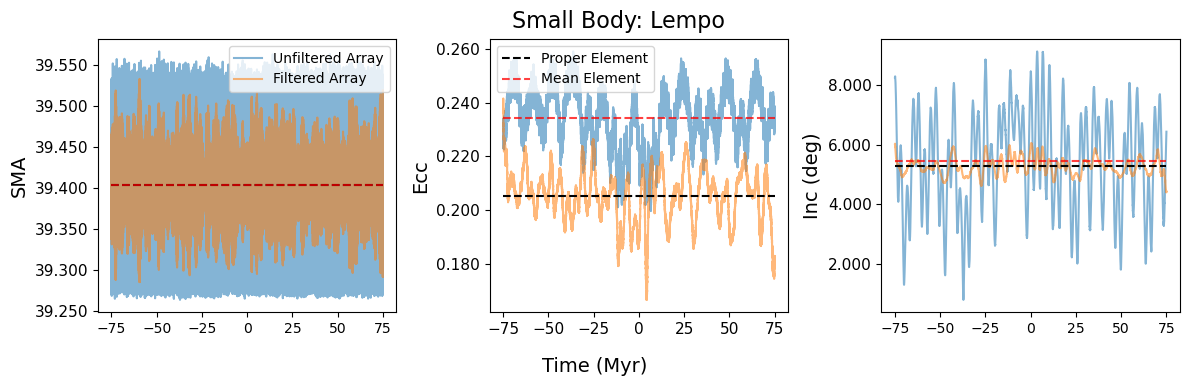

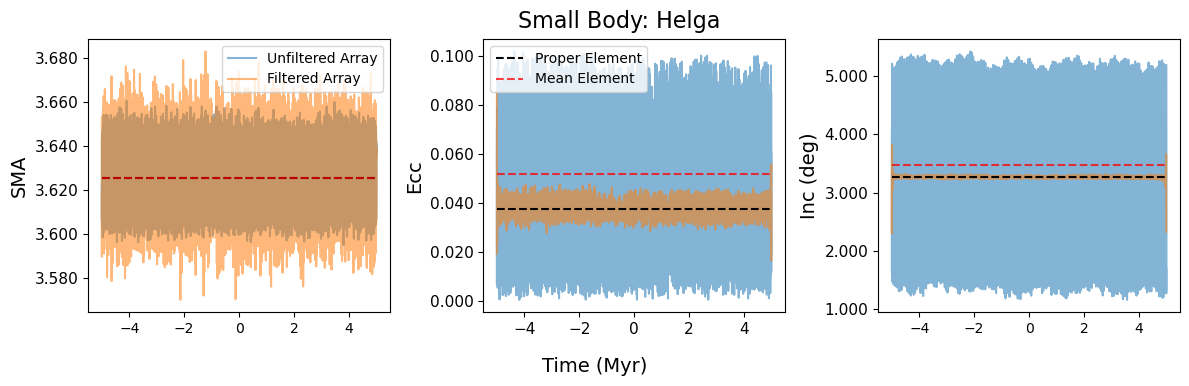

In [8]:
tno_result.proper_elements.plot_time_arrays()
ast_result.proper_elements.plot_time_arrays()

We can see evidence in all 3 orbital elements of chaotic motion in Lempo's orbit. While the semi-major axis evolution seems reasonable at first glance, the amplitude of the change in semi-major axis is larger than it would be for a stable object. In addition, we can see scattering effects in the osculating eccentricity and inclination evolution, as angular momentum exchange coincides with the chaotic energy exchange.

In addition, we can confirm that, as a Plutino with e>0.2, Lempo does experience a planet crossing orbit, with q<34. Indeed, the orbit intersects/crosses Neptune's orbit at peak values of e. 

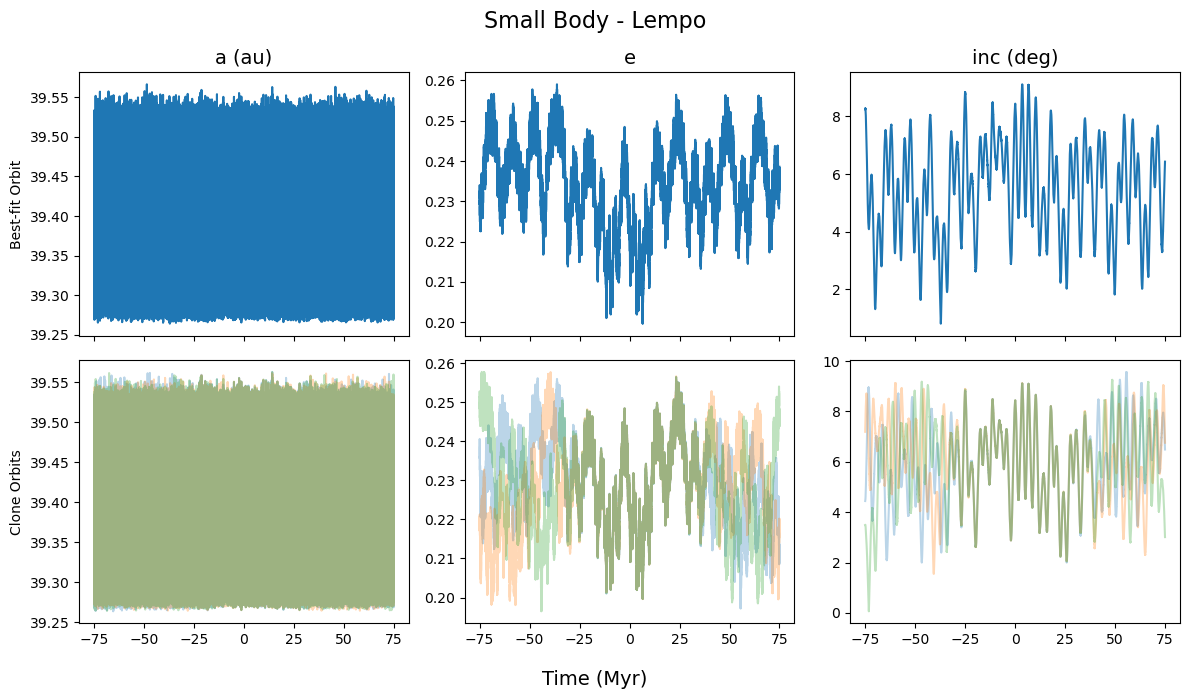

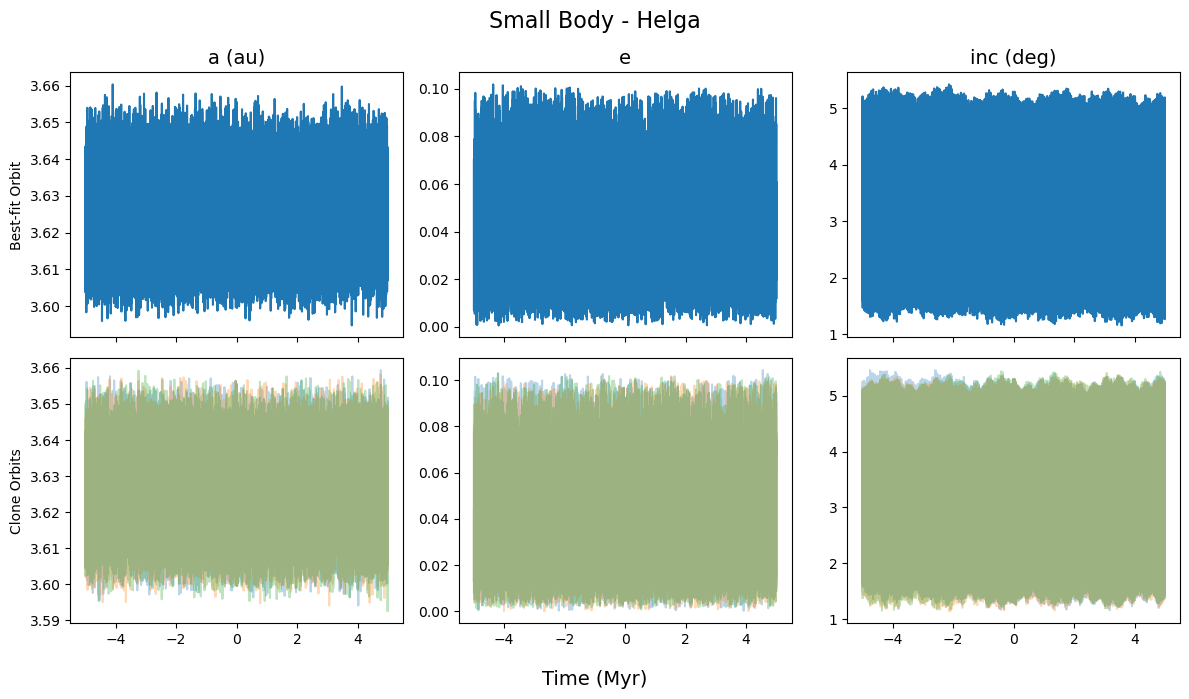

In [9]:
tno_result.stability_indicators.plot_clones()
ast_result.stability_indicators.plot_clones()

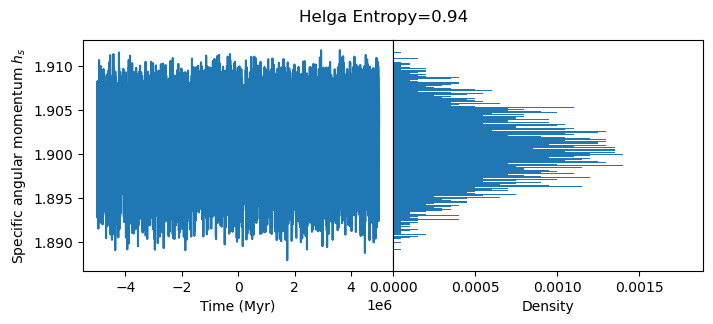

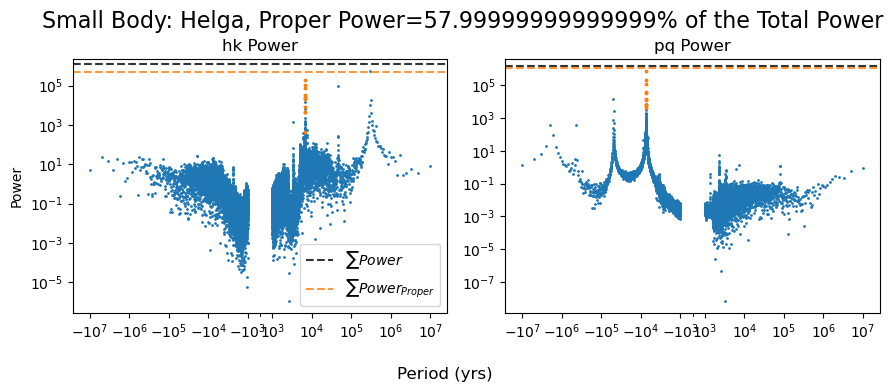

In [11]:
ast_result.stability_indicators.plot_entropy()
ast_result.stability_indicators.plot_power()